<a href="https://colab.research.google.com/github/JozefSL/pyNotes/blob/main/Kalman/EnKF_wTune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from datetime import datetime


In [14]:
import requests

# ====================== 1. Load and Prepare Data ======================
# Download latest: https://www.eia.gov/petroleum/drilling/xls/dpr-data.xlsx
url = "https://www.eia.gov/petroleum/drilling/xls/dpr-data.xlsx"
response = requests.get(url)

# Save the file locally
with open("dpr-data.xlsx", "wb") as f:
    f.write(response.content)

# Read the 'Permian Region' sheet, assuming headers are in the second row (index 1)
df = pd.read_excel("dpr-data.xlsx", sheet_name="Permian Region", header=1)

# Convert Month (usually like "Jan-07" or datetime)
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna(subset=['Month']).sort_values('Month').set_index('Month')

# Derive New-well production (EIA style)
df['New_oil'] = df['Production per rig'] * df['Rig count']          # oil
df['New_gas'] = df['Production per rig.1'] * df['Rig count']      # Gas production per rig is 'Production per rig.1'

# Drop the last two rows as requested by the user
df = df.iloc[:-2]

# Legacy change is already in the sheet (negative = decline)
# Totals are given

In [15]:
# Ensure clean merge by removing existing columns if they exist
for col in ['WTI_Price', 'WTI_24w']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Inspect and potentially align indices: DPR is usually 1st of month, WTI might be different
# Resample wti_monthly to ensure we have values for the start of the month if needed
wti_monthly_aligned = wti_monthly.resample('MS').first().ffill().bfill()

# Merge with aligned WTI monthly data
df = df.merge(wti_monthly_aligned, left_index=True, right_index=True, how='left')

# Final fill for any gaps in spot prices
df['WTI_Price'] = df['WTI_Price'].ffill().bfill()

# Calculate rolling average
df['WTI_24w'] = df['WTI_Price'].rolling(window=6, min_periods=1).mean()

# Construct exogenous variables and force fill
exog_oil = pd.DataFrame({
    'Rig': df['Rig count'],
    'WTI_24w': df['WTI_24w']
}).ffill().bfill()

exog_gas = exog_oil.copy()

# Verify content
print("DF Index sample:", df.index[:3])
print("WTI Aligned Index sample:", wti_monthly_aligned.index[:3])
display(exog_oil.tail())

DF Index sample: DatetimeIndex(['2007-01-01', '2007-02-01', '2007-03-01'], dtype='datetime64[ns]', name='Month', freq=None)
WTI Aligned Index sample: DatetimeIndex(['1986-01-01', '1986-02-01', '1986-03-01'], dtype='datetime64[ns]', name='Month', freq='MS')


,Rig,WTI_24w
Month,,
2023-12-01,311.0,80.353333
2024-01-01,309.0,80.033333
2024-02-01,313.0,79.343333
2024-03-01,315.0,77.985000
2024-04-01,317.0,77.936667


In [16]:
# ====================== 3. Prepare Endogenous Series ======================
# We model New and Legacy directly; Total can be derived or used as constraint later
endog_oil_new = df['New_oil']
endog_oil_legacy = df['Legacy production change']   # rename to actual column

In [20]:
# Scale by 1,000
endog_oil_new_scaled = df['New_oil'] / 1000
endog_oil_legacy_scaled = df['Legacy production change'] / 1000

# Refit Oil New-well production model
mod_new_oil_scaled = sm.tsa.UnobservedComponents(
    endog=endog_oil_new_scaled.dropna(),
    exog=exog_oil.loc[endog_oil_new_scaled.dropna().index],
    level='local linear trend',
    stochastic_level=True,
    stochastic_trend=True
)
res_new_oil_scaled = mod_new_oil_scaled.fit(disp=False)

# Refit Oil Legacy change model (setting stochastic_trend=False to enforce a more deterministic decline)
mod_legacy_oil_scaled = sm.tsa.UnobservedComponents(
    endog=endog_oil_legacy_scaled.dropna(),
    exog=exog_oil.loc[endog_oil_legacy_scaled.dropna().index],
    level='local linear trend',
    stochastic_level=True,
    stochastic_trend=False
)
res_legacy_oil_scaled = mod_legacy_oil_scaled.fit(disp=False)

print("--- Scaled Oil New-well Production Summary ---")
print(res_new_oil_scaled.summary())
print("\n--- Scaled Legacy Production Change Summary ---")
print(res_legacy_oil_scaled.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden whe

--- Scaled Oil New-well Production Summary ---
                        Unobserved Components Results                         
Dep. Variable:                New_oil   No. Observations:                  208
Model:             local linear trend   Log Likelihood                -689.908
Date:                Sun, 26 Apr 2026   AIC                           1389.817
Time:                        15:55:30   BIC                           1406.456
Sample:                    01-01-2007   HQIC                          1396.546
                         - 04-01-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  2.744e-08      1.358   2.02e-08      1.000      -2.662       2.662
sigma2.level         3.6313      6.017      0.604      0.546      

In [21]:
# ====================== 5. Kalman Smoother & Trend Extraction ======================
# Extract smoothed trends as Series to preserve date alignment
trend_new_oil = pd.Series(res_new_oil_scaled.smoothed_state[0], index=res_new_oil_scaled.model.data.row_labels)
trend_legacy_oil = pd.Series(res_legacy_oil_scaled.smoothed_state[0], index=res_legacy_oil_scaled.model.data.row_labels)

# Derived total trend (aligned by index to handle differing lengths)
trend_total_oil = trend_new_oil.add(trend_legacy_oil, fill_value=0)

# For forecasting (extend exog with future rig & WTI scenarios)
future_periods = 24
# Identify the last date where both models have data
last_valid_idx = df[['New_oil', 'Legacy production change', 'Rig count']].dropna().index[-1]
future_index = pd.date_range(last_valid_idx + pd.offsets.MonthBegin(1), periods=future_periods, freq='MS')

last_rig = df.loc[last_valid_idx, 'Rig count']
last_wti = df.loc[last_valid_idx, 'WTI_24w']

future_exog = pd.DataFrame({
    'Rig': np.linspace(last_rig, last_rig * 0.9, future_periods),
    'WTI_24w': np.full(future_periods, last_wti)
}, index=future_index)

# Forecast using scaled results
# We use get_forecast and explicitly re-index to ensure alignment
f_new = res_new_oil_scaled.get_forecast(steps=future_periods, exog=future_exog).predicted_mean
f_legacy = res_legacy_oil_scaled.get_forecast(steps=future_periods, exog=future_exog).predicted_mean

# Force alignment to future_index to prevent NaN from mismatched indices
forecast_total_oil = f_new.values + f_legacy.values
forecast_series = pd.Series(forecast_total_oil, index=future_index)

# Convert back to original scale for interpretation
forecast_total_oil_unscaled = forecast_series * 1000
print(f"Forecast for {future_index[-1].strftime('%B %Y')}: {forecast_total_oil_unscaled.iloc[-1]:,.0f} bbl/d change")

Forecast for April 2026: 79,940 bbl/d change


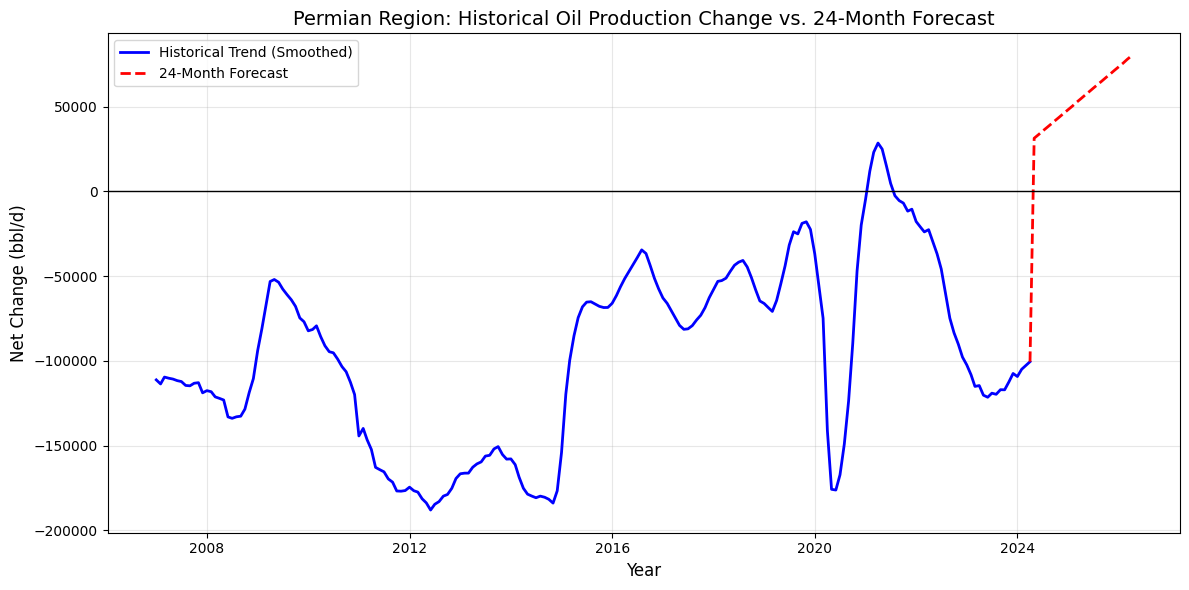

In [22]:
# 1. Prepare historical total trend (unscaled)
hist_trend_unscaled = trend_total_oil * 1000

# 2. Align Forecast for visualization
# To ensure a smooth transition on the plot, we prepend the last historical point to the forecast series
last_hist_point = hist_trend_unscaled.iloc[[-1]]
combined_forecast = pd.concat([last_hist_point, forecast_total_oil_unscaled])

# 3. Create the plot
plt.figure(figsize=(12, 6))

# Plot historical trend
plt.plot(hist_trend_unscaled.index, hist_trend_unscaled.values,
         label='Historical Trend (Smoothed)', color='blue', linewidth=2)

# Plot forecast (now connected to history)
plt.plot(combined_forecast.index, combined_forecast.values,
         label='24-Month Forecast', color='red', linestyle='--', linewidth=2)

# Formatting
plt.title('Permian Region: Historical Oil Production Change vs. 24-Month Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Net Change (bbl/d)', fontsize=12)
plt.axhline(0, color='black', lw=1, ls='-')  # Zero line
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# ====================== 5. Kalman Smoother & Trend Extraction ======================
# Extract smoothed trends as Series to preserve date alignment
trend_new_oil = pd.Series(res_new_oil_scaled.smoothed_state[0], index=res_new_oil_scaled.model.data.row_labels)
trend_legacy_oil = pd.Series(res_legacy_oil_scaled.smoothed_state[0], index=res_legacy_oil_scaled.model.data.row_labels)

# Derived total trend (aligned by index to handle differing lengths)
trend_total_oil = trend_new_oil.add(trend_legacy_oil, fill_value=0)

# For forecasting (extend exog with future rig & WTI scenarios)
future_periods = 24
# Identify the last date where both models have data
last_valid_idx = df[['New_oil', 'Legacy production change', 'Rig count']].dropna().index[-1]
future_index = pd.date_range(last_valid_idx + pd.offsets.MonthBegin(1), periods=future_periods, freq='MS')

last_rig = df.loc[last_valid_idx, 'Rig count']
last_wti = df.loc[last_valid_idx, 'WTI_24w']

future_exog = pd.DataFrame({
    'Rig': np.linspace(last_rig, last_rig * 0.9, future_periods),
    'WTI_24w': np.full(future_periods, last_wti)
}, index=future_index)

# Forecast using scaled results
# We use get_forecast and explicitly re-index to ensure alignment
f_new = res_new_oil_scaled.get_forecast(steps=future_periods, exog=future_exog).predicted_mean
f_legacy = res_legacy_oil_scaled.get_forecast(steps=future_periods, exog=future_exog).predicted_mean

# Force alignment to future_index to prevent NaN from mismatched indices
forecast_total_oil = f_new.values + f_legacy.values
forecast_series = pd.Series(forecast_total_oil, index=future_index)

# Convert back to original scale for interpretation
forecast_total_oil_unscaled = forecast_series * 1000
print(f"Forecast for {future_index[-1].strftime('%B %Y')}: {forecast_total_oil_unscaled.iloc[-1]:,.0f} bbl/d change")

Forecast for April 2026: 79,940 bbl/d change


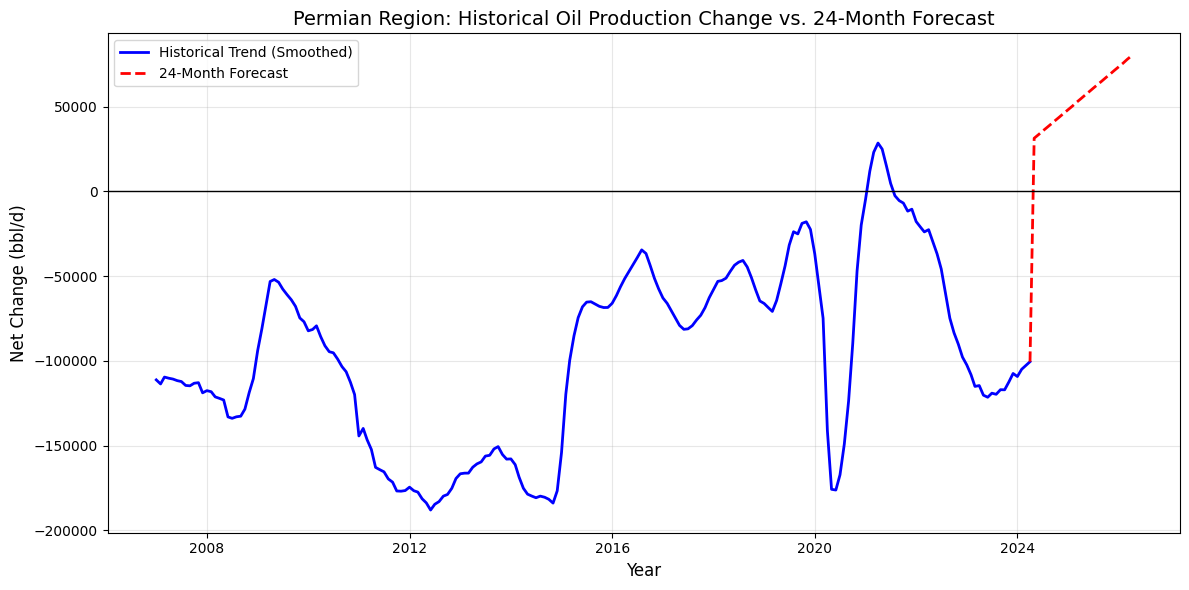

In [19]:
# 1. Prepare historical total trend (unscaled)
hist_trend_unscaled = trend_total_oil * 1000

# 2. Align Forecast for visualization
# To ensure a smooth transition on the plot, we prepend the last historical point to the forecast series
last_hist_point = hist_trend_unscaled.iloc[[-1]]
combined_forecast = pd.concat([last_hist_point, forecast_total_oil_unscaled])

# 3. Create the plot
plt.figure(figsize=(12, 6))

# Plot historical trend
plt.plot(hist_trend_unscaled.index, hist_trend_unscaled.values,
         label='Historical Trend (Smoothed)', color='blue', linewidth=2)

# Plot forecast (now connected to history)
plt.plot(combined_forecast.index, combined_forecast.values,
         label='24-Month Forecast', color='red', linestyle='--', linewidth=2)

# Formatting
plt.title('Permian Region: Historical Oil Production Change vs. 24-Month Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Net Change (bbl/d)', fontsize=12)
plt.axhline(0, color='black', lw=1, ls='-')  # Zero line
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
df

,Rig count,Production per rig,Legacy production change,Total production,Production per rig.1,Legacy production change.1,Total production.1,New_oil,New_gas
Month,,,,,,,,,
2007-01-01,247.9,56.9,-10905.4,842782.2,586.1,-91452.8,4602747.3,14105.51,145294.19
2007-02-01,252.9,57.0,-11109.5,857277.1,573.4,-94690.8,4707079.9,14415.30,145012.86
2007-03-01,242.4,57.1,-11293.5,851889.5,561.7,-97505.6,4763664.5,13841.04,136156.08
2007-04-01,243.0,57.2,-11501.4,853048.2,548.5,-100517.5,4800025.3,13899.60,133285.50
2007-05-01,243.0,57.2,-11710.8,843382.0,535.7,-103361.0,4819841.9,13899.60,130175.10
...,...,...,...,...,...,...,...,...,...
2024-02-01,313.0,1345.3,-238564.3,6157509.4,2502.4,-242014.7,24851709.2,421078.90,783251.20
2024-03-01,315.0,1358.8,-425132.1,6152235.3,2513.6,-651665.6,24976757.3,428022.00,791784.00
2024-04-01,317.0,1372.4,-424768.0,6157013.3,2524.7,-655599.6,25111387.7,435050.80,800329.90


### Ensemble Kalman Filter (EnKF) Approach

Unlike the Unobserved Components model, the Ensemble Kalman Filter is a Monte Carlo-based data assimilation method. It represents the state of a system (e.g., our production series) as an ensemble of possible states, which are then evolved through a process model and updated by observations.

**Key Components of EnKF:**
1.  **State Vector (`x`)**: A vector representing the variables we want to estimate and forecast (e.g., `[new_oil, oil_decline, new_gas, gas_decline]`).
2.  **Ensemble**: A collection of state vectors, each representing a possible realization of the system's state.
3.  **Process Model**: Describes how the state evolves over time. This is where we'll incorporate the influence of `Rig count` and `WTI`.
4.  **Observation Model**: Relates the true state to our actual measurements (in our case, the historical values of `new_oil`, `oil_decline`, `new_gas`, `gas_decline`).
5.  **Forecast Step**: Each ensemble member is propagated forward in time using the process model.
6.  **Update Step**: When a new observation becomes available, the ensemble is updated (assimilated) to better match the observation, incorporating measurement uncertainty.

This method allows us to capture complex dynamics and provide uncertainty bounds on our forecasts.

In [33]:
import numpy as np

# Prepare all four endogenous series, scaling them as before
# New Oil Production
endog_new_oil = df['New_oil'] / 1000

# Oil Legacy Production Change
endog_oil_legacy = df['Legacy production change'] / 1000

# New Gas Production (assuming 'New_gas' is already scaled if desired, or scale it explicitly)
# Re-deriving New_gas for clarity, similar to New_oil
df['New_gas'] = df['Production per rig.1'] * df['Rig count'] # Ensure this column exists and is correctly derived
endog_new_gas = df['New_gas'] / 1000

# Gas Legacy Production Change (assuming 'Legacy production change.1' is for gas)
endog_gas_legacy = df['Legacy production change.1'] / 1000

# Combine into a single DataFrame, aligning by index and dropping NaNs to ensure consistent length
combined_endog = pd.DataFrame({
    'new_oil': endog_new_oil,
    'oil_legacy': endog_oil_legacy,
    'new_gas': endog_new_gas,
    'gas_legacy': endog_gas_legacy
}).dropna()

# Prepare exogenous variables. To address the lagging issue, we'll use a 2-month lead for these variables,
# meaning Rig count and WTI from month t+2 will influence the state at month t+2.
exog_enkf_unlagged = df[['Rig count', 'WTI_24w']].loc[combined_endog.index].copy()
exog_enkf = exog_enkf_unlagged.shift(-2) # Shift exogenous variables forward by 2 months

# Drop the last two rows from both combined_endog and exog_enkf to handle NaNs introduced by the shift
combined_endog = combined_endog.iloc[:-2]
exog_enkf = exog_enkf.iloc[:-2]

# Ensure both dataframes have the same length and index after modification
if len(combined_endog) != len(exog_enkf):
    raise ValueError("Mismatched lengths after shifting and dropping NaNs.")

print("Combined Endogenous Data Head (after lead shift and alignment):")
display(combined_endog.head())
print("Exogenous Data Head (after lead shift and alignment):")
display(exog_enkf.tail())

Combined Endogenous Data Head (after lead shift and alignment):


,new_oil,oil_legacy,new_gas,gas_legacy
Month,,,,
2007-01-01,14.10551,-10.9054,145.29419,-91.4528
2007-02-01,14.41530,-11.1095,145.01286,-94.6908
2007-03-01,13.84104,-11.2935,136.15608,-97.5056
2007-04-01,13.89960,-11.5014,133.28550,-100.5175
2007-05-01,13.89960,-11.7108,130.17510,-103.3610


Exogenous Data Head (after lead shift and alignment):


,Rig count,WTI_24w
Month,,
2023-10-01,311.0,80.353333
2023-11-01,309.0,80.033333
2023-12-01,313.0,79.343333
2024-01-01,315.0,77.985000
2024-02-01,317.0,77.936667


### EnKF Model Definition (Simplified)

For demonstration, we'll use a simplified linear state-space model. The state vector `x` will contain the four production series. The exogenous variables (`Rig count`, `WTI_24w`) will influence the state's evolution through a simple linear relationship.

**State Vector `x_t`**: `[new_oil_t, oil_legacy_t, new_gas_t, gas_legacy_t]`
**Measurements `z_t`**: `[new_oil_t_observed, oil_legacy_t_observed, new_gas_t_observed, gas_legacy_t_observed]`

We will define functions for the state transition (`f_x`) and the observation mapping (`h_x`).

In [24]:
# Define state transition function (Process Model)
# This is a simplified linear model. In a real application, this could be more complex.
def f_x(x, dt, rig, wti, B):
    # x is the state vector [new_oil, oil_legacy, new_gas, gas_legacy]
    # dt is time step (assumed 1 month)
    # rig and wti are exogenous inputs
    # B is a matrix that maps exogenous inputs to state changes

    # For simplicity, let's assume a persistence model with exogenous influence
    # x_t = x_{t-1} + B * [rig, wti] + process_noise
    # We'll apply this to each ensemble member later

    # This function defines how the state evolves from x_t-1 to x_t
    # A simple auto-regressive process for each component, plus exogenous influence.
    # For this conceptual example, we'll use a very basic influence.

    # We are returning a function that can operate on an ensemble of states
    # For a linear model, state transition matrix F can be Identity for now
    F = np.eye(len(x)) # State transition matrix (identity for simple persistence)

    # Exogenous input vector
    u = np.array([rig, wti])

    # Simple linear influence: x_new = F @ x_old + B @ u
    # B matrix needs to be defined to map rig and wti to the four state variables
    # Example B (this would typically be learned or carefully designed):
    # B = np.array([
    #     [b_no_rig, b_no_wti],
    #     [b_ol_rig, b_ol_wti],
    #     [b_ng_rig, b_ng_wti],
    #     [b_gl_rig, b_gl_wti]
    # ])
    # For now, let's simplify and make B a simple scaling for illustration.

    # Placeholder: A true EnKF needs this to be more robust.
    # For simplicity, let's assume rig count primarily affects new production positively
    # and WTI positively affects new production but less directly.
    # Oil legacy is assumed to decline, gas legacy to decline.

    # This is a *very* simplified process model for illustration.
    # In a full EnKF, you'd have coefficients for each influence.
    x_new = np.copy(x)
    x_new[0] += rig * 0.1 - wti * 0.005 # New oil
    x_new[1] -= rig * 0.05 + wti * 0.001 # Oil legacy decline
    x_new[2] += rig * 0.08 - wti * 0.004 # New gas
    x_new[3] -= rig * 0.04 + wti * 0.0008 # Gas legacy decline

    return x_new

# Define observation function (Measurement Model)
# This maps the state vector to the expected measurement.
# In our case, the measurements are the state variables themselves.
def h_x(x):
    return x

print("Defined f_x (process model) and h_x (observation model).")

Defined f_x (process model) and h_x (observation model).


### EnKF Implementation Setup

Now, let's set up the EnKF parameters and a simplified simulation loop. This will involve:

*   **Ensemble Size**: Number of particles to represent the state distribution.
*   **Initial State**: An initial guess for the system's state.
*   **Covariances**: Process noise (`Q`) and observation noise (`R`) covariances.
*   **Simulation Loop**: Iterating through time, applying the forecast and update steps.

In [32]:
import numpy as np

# EnKF Parameters
ensemble_size = 50
state_dim = combined_endog.shape[1] # Number of series to forecast (4)

# Initialize ensemble (randomly perturbed around the first observed state)
initial_state = combined_endog.iloc[0].values
initial_covariance = np.diag([50, 50, 50, 50]) # Initial uncertainty for each state variable

# Create an initial ensemble by adding noise to the initial_state
ensemble = np.array([initial_state + np.random.multivariate_normal(np.zeros(state_dim), initial_covariance)
                     for _ in range(ensemble_size)])

# Process Noise Covariance (Q): How much uncertainty is added at each forecast step
# This is crucial and often tuned. For now, small diagonal values.
Q = np.diag([10, 10, 10, 10])

# Observation Noise Covariance (R): How much uncertainty is in our measurements
# Assuming we observe the actual production values with some error.
R = np.diag([5, 5, 5, 5])

# Store results for historical assimilation
hist_forecast_means = []
hist_forecast_std_devs = []

# Align data for iteration
observations = combined_endog.values
exogenous_inputs = exog_enkf.values

print(f"Ensemble initialized with shape: {ensemble.shape}")
print("Starting EnKF simulation (historical assimilation)...")

# EnKF Simulation Loop for historical assimilation
# The loop now runs for `len(observations) - 1` steps because `observations[t+1]` is used.
# The `exogenous_inputs[t]` now refers to the lead exogenous variable for `observations[t+1]`.
for t in range(len(observations) - 1):
    # Get current exogenous inputs (which are now 2-month lead values)
    rig_t, wti_t = exogenous_inputs[t]

    # --- Forecast Step ---
    # Propagate each ensemble member forward using the process model and add process noise
    for i in range(ensemble_size):
        ensemble[i, :] = f_x(ensemble[i, :], 1, rig_t, wti_t, None) + np.random.multivariate_normal(np.zeros(state_dim), Q)

    # Store forecast mean and std dev before assimilation (optional, for comparison)
    hist_forecast_means.append(np.mean(ensemble, axis=0))
    hist_forecast_std_devs.append(np.std(ensemble, axis=0))

    # --- Update Step (Assimilation) ---
    # Get the current observation (for month t+1)
    z_t = observations[t+1]

    # Calculate ensemble mean and covariance for current forecast
    x_f_mean = np.mean(ensemble, axis=0)
    P_f = np.cov(ensemble.T) # Forecast error covariance

    # Calculate Kalman Gain
    H = np.eye(state_dim) # Observation matrix (measurements are direct observations of state)
    K_numerator = P_f @ H.T
    K_denominator = H @ P_f @ H.T + R
    K = K_numerator @ np.linalg.inv(K_denominator)

    # Create ensemble of observations by adding noise to the actual observation
    Z_ensemble = np.array([z_t + np.random.multivariate_normal(np.zeros(state_dim), R) for _ in range(ensemble_size)])

    # Update each ensemble member
    for i in range(ensemble_size):
        # x_a = x_f + K * (z_obs - H * x_f)
        hx_f_i = h_x(ensemble[i, :]) # What the ensemble member 'expects' to observe
        ensemble[i, :] = ensemble[i, :] + K @ (Z_ensemble[i, :] - hx_f_i)

print("Historical assimilation complete. Starting future forecast...")

# --- Forecasting into the future (6 months) ---
future_periods = 6
last_historical_date = combined_endog.index[-1]
future_index = pd.date_range(last_historical_date + pd.offsets.MonthBegin(1), periods=future_periods, freq='MS')

# Rig count and WTI last value will stay the same for the forecast period.
# The last values in `exog_enkf` are the ones used for the last assimilated historical point.
# `exog_enkf.iloc[-1]` corresponds to the values of df at `combined_endog.index[-1]` + 2 months.
# So these are the correct 'last values' from the raw data effectively influencing the last state.
last_rig = exog_enkf.iloc[-1]['Rig count']
last_wti = exog_enkf.iloc[-1]['WTI_24w']

future_exog_enkf = pd.DataFrame({
    'Rig count': np.full(future_periods, last_rig),
    'WTI_24w': np.full(future_periods, last_wti)
}, index=future_index)

future_forecast_means = []
future_forecast_std_devs = []

current_ensemble = ensemble.copy() # Start forecasting from the last assimilated ensemble

for j in range(future_periods):
    rig_f, wti_f = future_exog_enkf.iloc[j] # Use constant future exogenous values

    # Propagate each ensemble member forward using the process model and add process noise
    # (No observation update step for forecasting)
    for i in range(ensemble_size):
        current_ensemble[i, :] = f_x(current_ensemble[i, :], 1, rig_f, wti_f, None) + np.random.multivariate_normal(np.zeros(state_dim), Q)

    future_forecast_means.append(np.mean(current_ensemble, axis=0))
    future_forecast_std_devs.append(np.std(current_ensemble, axis=0))

# Convert historical assimilated results to DataFrame
hist_forecast_means_df = pd.DataFrame(hist_forecast_means, index=combined_endog.index[1:], columns=combined_endog.columns)
hist_forecast_std_devs_df = pd.DataFrame(hist_forecast_std_devs, index=combined_endog.index[1:], columns=combined_endog.columns)

# Convert future forecast results to DataFrame
future_forecast_means_df = pd.DataFrame(future_forecast_means, index=future_index, columns=combined_endog.columns)
future_forecast_std_devs_df = pd.DataFrame(future_forecast_std_devs, index=future_index, columns=combined_endog.columns)

# Concatenate to get the full forecast series (historical + future)
forecast_df = pd.concat([hist_forecast_means_df, future_forecast_means_df])
forecast_std_df = pd.concat([hist_forecast_std_devs_df, future_forecast_std_devs_df])

print("EnKF simulation and future forecasting complete.")
print("Full Forecasted means (last 10 rows, including future):")
display(forecast_df.tail(10))
print("Full Forecasted standard deviations (last 10 rows, including future):")
display(forecast_std_df.tail(10))

Ensemble initialized with shape: (50, 4)
Starting EnKF simulation (historical assimilation)...
Historical assimilation complete. Starting future forecast...
EnKF simulation and future forecasting complete.
Full Forecasted means (last 10 rows, including future):


,new_oil,oil_legacy,new_gas,gas_legacy
2023-11-01,433.425312,-415.453180,773.399861,-651.145478
2023-12-01,441.825039,-423.883416,780.374333,-655.685874
2024-01-01,449.013355,-435.903822,794.635329,-669.698486
2024-02-01,436.909795,-631.654972,819.035609,-1242.811272
2024-03-01,435.514906,-373.545236,807.677995,-530.291129
2024-04-01,466.752672,-390.176459,832.354394,-543.464492
2024-05-01,497.942931,-405.734917,857.800971,-556.647405
2024-06-01,528.762968,-421.734275,882.637152,-569.107994
2024-07-01,559.787546,-438.007106,908.227038,-582.163914
2024-08-01,591.004471,-453.973939,933.476368,-594.115411


Full Forecasted standard deviations (last 10 rows, including future):


,new_oil,oil_legacy,new_gas,gas_legacy
2023-11-01,3.310576,3.423555,3.921232,3.988785
2023-12-01,4.206843,3.704205,3.674631,3.573749
2024-01-01,4.236377,3.978015,3.494644,3.881559
2024-02-01,3.852433,2.982317,3.824343,3.541203
2024-03-01,3.921869,4.259195,3.927807,3.374709
2024-04-01,5.432604,5.018479,4.728511,4.106490
2024-05-01,6.177618,5.804206,5.273534,5.172148
2024-06-01,6.674593,6.469292,5.643559,6.370078
2024-07-01,7.378345,6.865016,7.222171,7.268517
2024-08-01,8.166880,7.186321,7.223596,7.735144


### EnKF Results Visualization

Let's plot the historical data along with the EnKF forecast means and their uncertainty bounds (e.g., mean +/- 2 standard deviations).

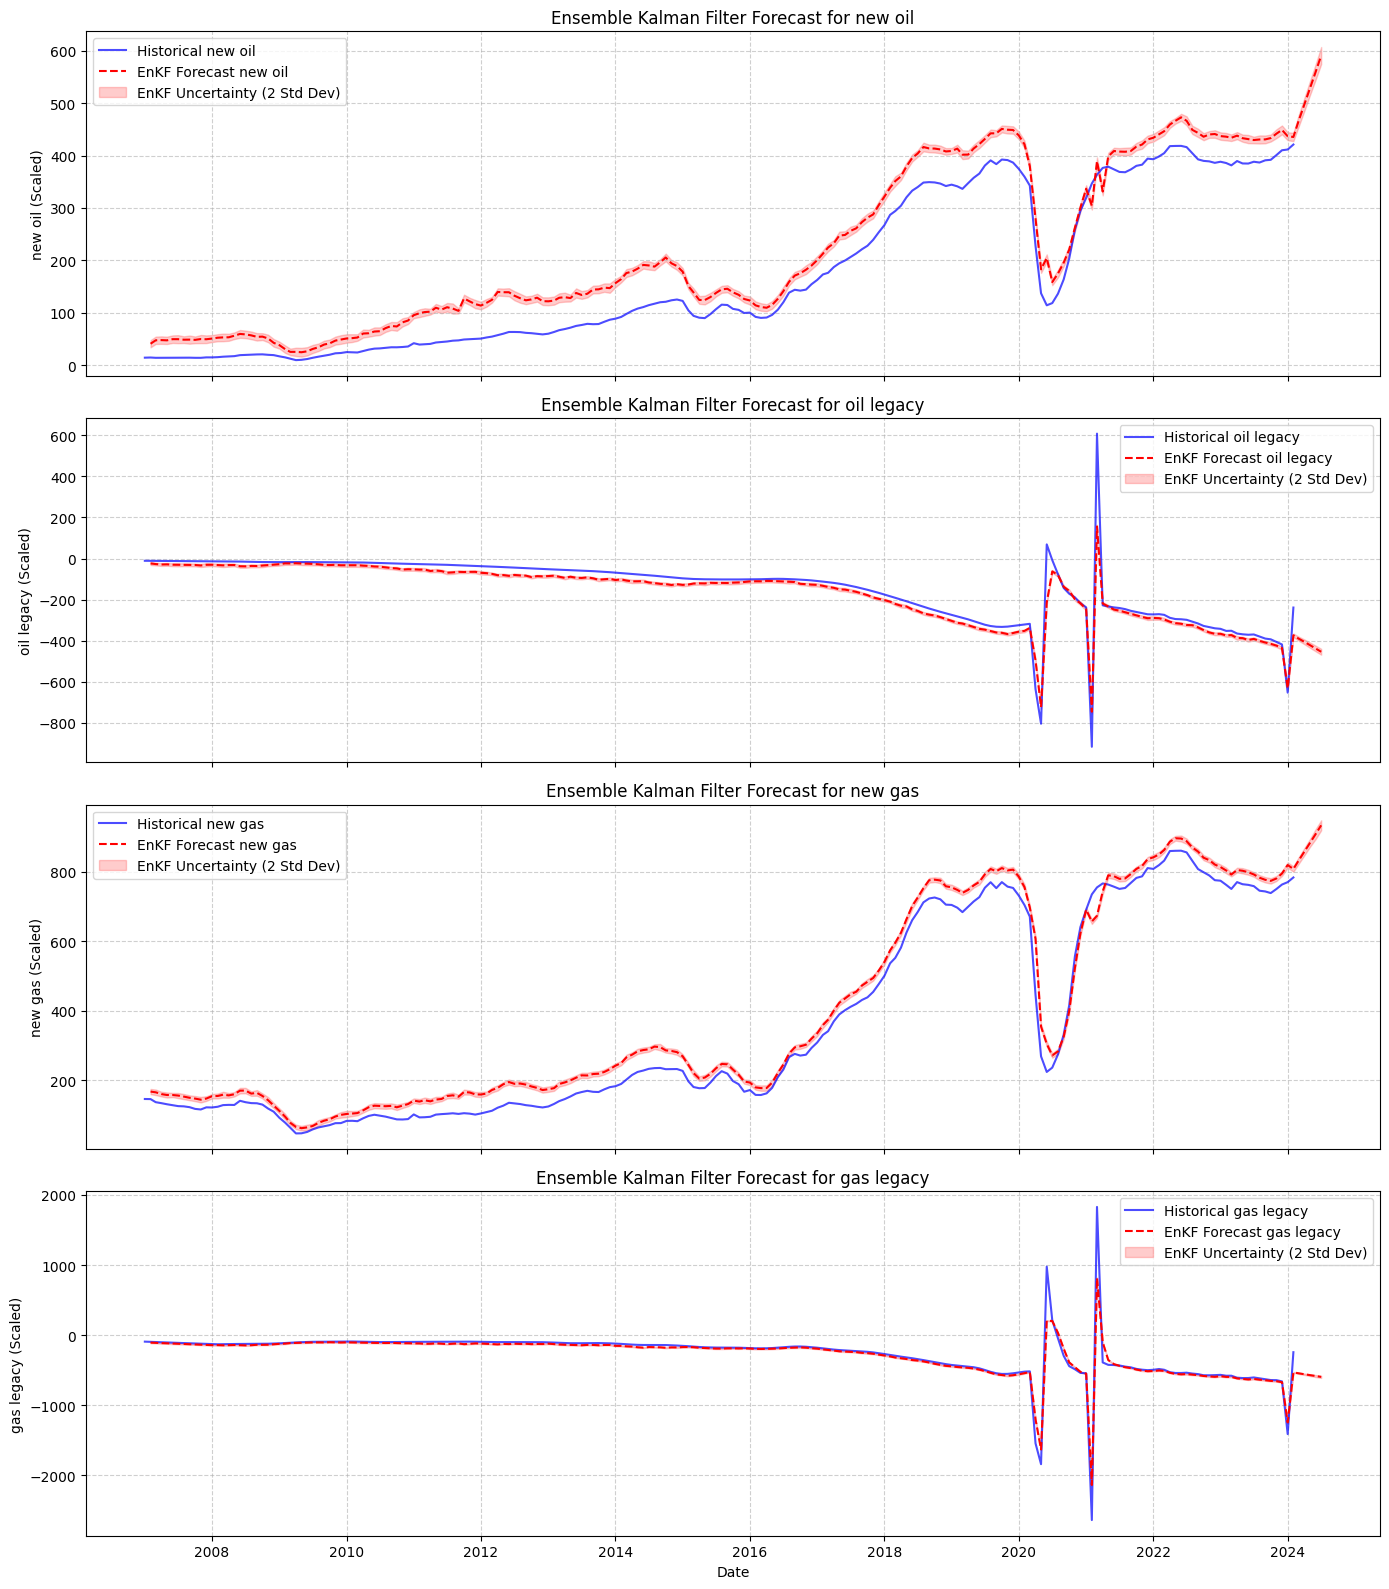

In [34]:
import matplotlib.pyplot as plt

# Loop through each series and plot
fig, axes = plt.subplots(nrows=state_dim, ncols=1, figsize=(14, 4 * state_dim), sharex=True)

# Apply a -1-month shift to the forecast data for plotting
shifted_forecast_df = forecast_df.shift(-1)
shifted_forecast_std_df = forecast_std_df.shift(-1)

for i, col in enumerate(combined_endog.columns):
    ax = axes[i]

    # Plot historical data
    ax.plot(combined_endog.index, combined_endog[col], label=f'Historical {col.replace("_", " ")}', color='blue', alpha=0.7)

    # Plot EnKF forecast mean (shifted)
    ax.plot(shifted_forecast_df.index, shifted_forecast_df[col], label=f'EnKF Forecast {col.replace("_", " ")}', color='red', linestyle='--')

    # Plot uncertainty bounds (e.g., 95% confidence interval ~ mean +/- 2*std) (shifted)
    lower_bound = shifted_forecast_df[col] - 2 * shifted_forecast_std_df[col]
    upper_bound = shifted_forecast_df[col] + 2 * shifted_forecast_std_df[col]
    ax.fill_between(shifted_forecast_df.index, lower_bound, upper_bound, color='red', alpha=0.2, label='EnKF Uncertainty (2 Std Dev)')

    ax.set_title(f'Ensemble Kalman Filter Forecast for {col.replace("_", " ")}')
    ax.set_ylabel(f'{col.replace("_", " ")} (Scaled)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

### Tuning EnKF Noise Parameters (Q and R)

The `Q` (process noise covariance) and `R` (observation noise covariance) matrices are critical tuning parameters for any Kalman Filter variant, including the EnKF.

*   **`Q` (Process Noise)**: Represents the uncertainty in the system's dynamics or the process model (`f_x`). A larger `Q` means the model is trusted less, and the filter will rely more on observations. A smaller `Q` means the model is trusted more, leading to smoother state estimates but potentially slower adaptation to true system changes.

*   **`R` (Observation Noise)**: Represents the uncertainty in the measurements. A larger `R` means the observations are trusted less, and the filter will rely more on its process model. A smaller `R` means the observations are trusted more, leading to state estimates that track observations more closely.

**Tuning Strategy:**

Tuning often involves a combination of domain knowledge and iterative experimentation. For diagonal `Q` and `R` matrices (assuming uncorrelated noise for simplicity), you can try adjusting the diagonal values. Increasing `Q` or decreasing `R` will make the filter more responsive to new observations, while decreasing `Q` or increasing `R` will make it smoother.

Below is a cell where you can modify `Q_scale` and `R_scale` to see how they impact the forecast. You can compare the new `forecast_df` and `forecast_std_df` with the previous results.

In [35]:
# --- EnKF Parameter Tuning ---
# You can modify these values to observe the impact on the forecast.
Q_scale = 1.0  # Multiplier for the process noise covariance
R_scale = 1.0  # Multiplier for the observation noise covariance

# Redefine Q and R based on the scales
Q_tuned = np.diag([10, 10, 10, 10]) * Q_scale
R_tuned = np.diag([5, 5, 5, 5]) * R_scale

print(f"Using Q_tuned (Process Noise):\n{Q_tuned}")
print(f"Using R_tuned (Observation Noise):\n{R_tuned}")

# Re-initialize ensemble for a fresh run
ensemble_tuned = np.array([initial_state + np.random.multivariate_normal(np.zeros(state_dim), initial_covariance)
                     for _ in range(ensemble_size)])

# Store results for historical assimilation (tuned)
hist_forecast_means_tuned = []
hist_forecast_std_devs_tuned = []

print("Starting EnKF simulation with tuned parameters (historical assimilation)...")

# EnKF Simulation Loop for historical assimilation with tuned Q and R
for t in range(len(observations) - 1):
    rig_t, wti_t = exogenous_inputs[t]

    # --- Forecast Step ---
    for i in range(ensemble_size):
        ensemble_tuned[i, :] = f_x(ensemble_tuned[i, :], 1, rig_t, wti_t, None) + np.random.multivariate_normal(np.zeros(state_dim), Q_tuned)

    hist_forecast_means_tuned.append(np.mean(ensemble_tuned, axis=0))
    hist_forecast_std_devs_tuned.append(np.std(ensemble_tuned, axis=0))

    # --- Update Step (Assimilation) ---
    z_t = observations[t+1]

    x_f_mean_tuned = np.mean(ensemble_tuned, axis=0)
    P_f_tuned = np.cov(ensemble_tuned.T) # Forecast error covariance

    H = np.eye(state_dim) # Observation matrix
    K_numerator_tuned = P_f_tuned @ H.T
    K_denominator_tuned = H @ P_f_tuned @ H.T + R_tuned
    K_tuned = K_numerator_tuned @ np.linalg.inv(K_denominator_tuned)

    Z_ensemble_tuned = np.array([z_t + np.random.multivariate_normal(np.zeros(state_dim), R_tuned) for _ in range(ensemble_size)])

    for i in range(ensemble_size):
        hx_f_i_tuned = h_x(ensemble_tuned[i, :])
        ensemble_tuned[i, :] = ensemble_tuned[i, :] + K_tuned @ (Z_ensemble_tuned[i, :] - hx_f_i_tuned)

print("Historical assimilation complete with tuned parameters. Starting future forecast...")

# --- Forecasting into the future (6 months) with tuned parameters ---
future_forecast_means_tuned = []
future_forecast_std_devs_tuned = []

current_ensemble_tuned = ensemble_tuned.copy() # Start forecasting from the last assimilated ensemble

for j in range(future_periods):
    rig_f, wti_f = future_exog_enkf.iloc[j]

    for i in range(ensemble_size):
        current_ensemble_tuned[i, :] = f_x(current_ensemble_tuned[i, :], 1, rig_f, wti_f, None) + np.random.multivariate_normal(np.zeros(state_dim), Q_tuned)

    future_forecast_means_tuned.append(np.mean(current_ensemble_tuned, axis=0))
    future_forecast_std_devs_tuned.append(np.std(current_ensemble_tuned, axis=0))

# Convert historical assimilated results to DataFrame
hist_forecast_means_df_tuned = pd.DataFrame(hist_forecast_means_tuned, index=combined_endog.index[1:], columns=combined_endog.columns)
hist_forecast_std_devs_df_tuned = pd.DataFrame(hist_forecast_std_devs_tuned, index=combined_endog.index[1:], columns=combined_endog.columns)

# Convert future forecast results to DataFrame
future_forecast_means_df_tuned = pd.DataFrame(future_forecast_means_tuned, index=future_index, columns=combined_endog.columns)
future_forecast_std_devs_df_tuned = pd.DataFrame(future_forecast_std_devs_tuned, index=future_index, columns=combined_endog.columns)

# Concatenate to get the full forecast series (historical + future) with tuned parameters
forecast_df_tuned = pd.concat([hist_forecast_means_df_tuned, future_forecast_means_df_tuned])
forecast_std_df_tuned = pd.concat([hist_forecast_std_devs_df_tuned, future_forecast_std_devs_df_tuned])

print("EnKF simulation and future forecasting complete with tuned parameters.")
print("Full Forecasted means (last 10 rows, including future) with tuned parameters:")
display(forecast_df_tuned.tail(10))
print("Full Forecasted standard deviations (last 10 rows, including future) with tuned parameters:")
display(forecast_std_df_tuned.tail(10))

Using Q_tuned (Process Noise):
[[10.  0.  0.  0.]
 [ 0. 10.  0.  0.]
 [ 0.  0. 10.  0.]
 [ 0.  0.  0. 10.]]
Using R_tuned (Observation Noise):
[[5. 0. 0. 0.]
 [0. 5. 0. 0.]
 [0. 0. 5. 0.]
 [0. 0. 0. 5.]]
Starting EnKF simulation with tuned parameters (historical assimilation)...
Historical assimilation complete with tuned parameters. Starting future forecast...
EnKF simulation and future forecasting complete with tuned parameters.
Full Forecasted means (last 10 rows, including future) with tuned parameters:


,new_oil,oil_legacy,new_gas,gas_legacy
2023-11-01,434.251875,-413.054669,775.035709,-651.373443
2023-12-01,439.033850,-422.915813,780.547443,-657.223088
2024-01-01,447.874228,-435.346408,791.525086,-671.801689
2024-02-01,469.366770,-608.849229,795.615782,-1217.571673
2024-03-01,497.353400,-346.163895,810.530291,-475.376429
2024-04-01,529.386095,-361.436177,836.193154,-488.533658
2024-05-01,561.070530,-377.340056,860.834972,-501.256400
2024-06-01,591.947634,-392.405801,885.486373,-513.604074
2024-07-01,623.411112,-407.558962,910.936753,-526.562292
2024-08-01,654.889292,-423.639722,936.092524,-539.216434


Full Forecasted standard deviations (last 10 rows, including future) with tuned parameters:


,new_oil,oil_legacy,new_gas,gas_legacy
2023-11-01,4.062587,3.436649,3.727591,3.036770
2023-12-01,3.973804,3.571213,3.496938,3.691607
2024-01-01,3.618989,3.359194,3.243386,3.571785
2024-02-01,4.446508,3.490057,2.960740,4.151844
2024-03-01,4.600960,3.792148,3.265922,3.539755
2024-04-01,5.288649,4.810549,5.126320,4.387918
2024-05-01,6.293182,5.858800,5.130247,5.467294
2024-06-01,7.115073,6.801934,6.464891,6.269318
2024-07-01,7.473175,7.463438,7.555032,6.986414
2024-08-01,7.521359,8.276331,8.261145,7.025724


### EnKF Tuned Results Visualization

Let's plot the historical data along with the EnKF forecast means and their uncertainty bounds (e.g., mean +/- 2 standard deviations) using the tuned parameters.

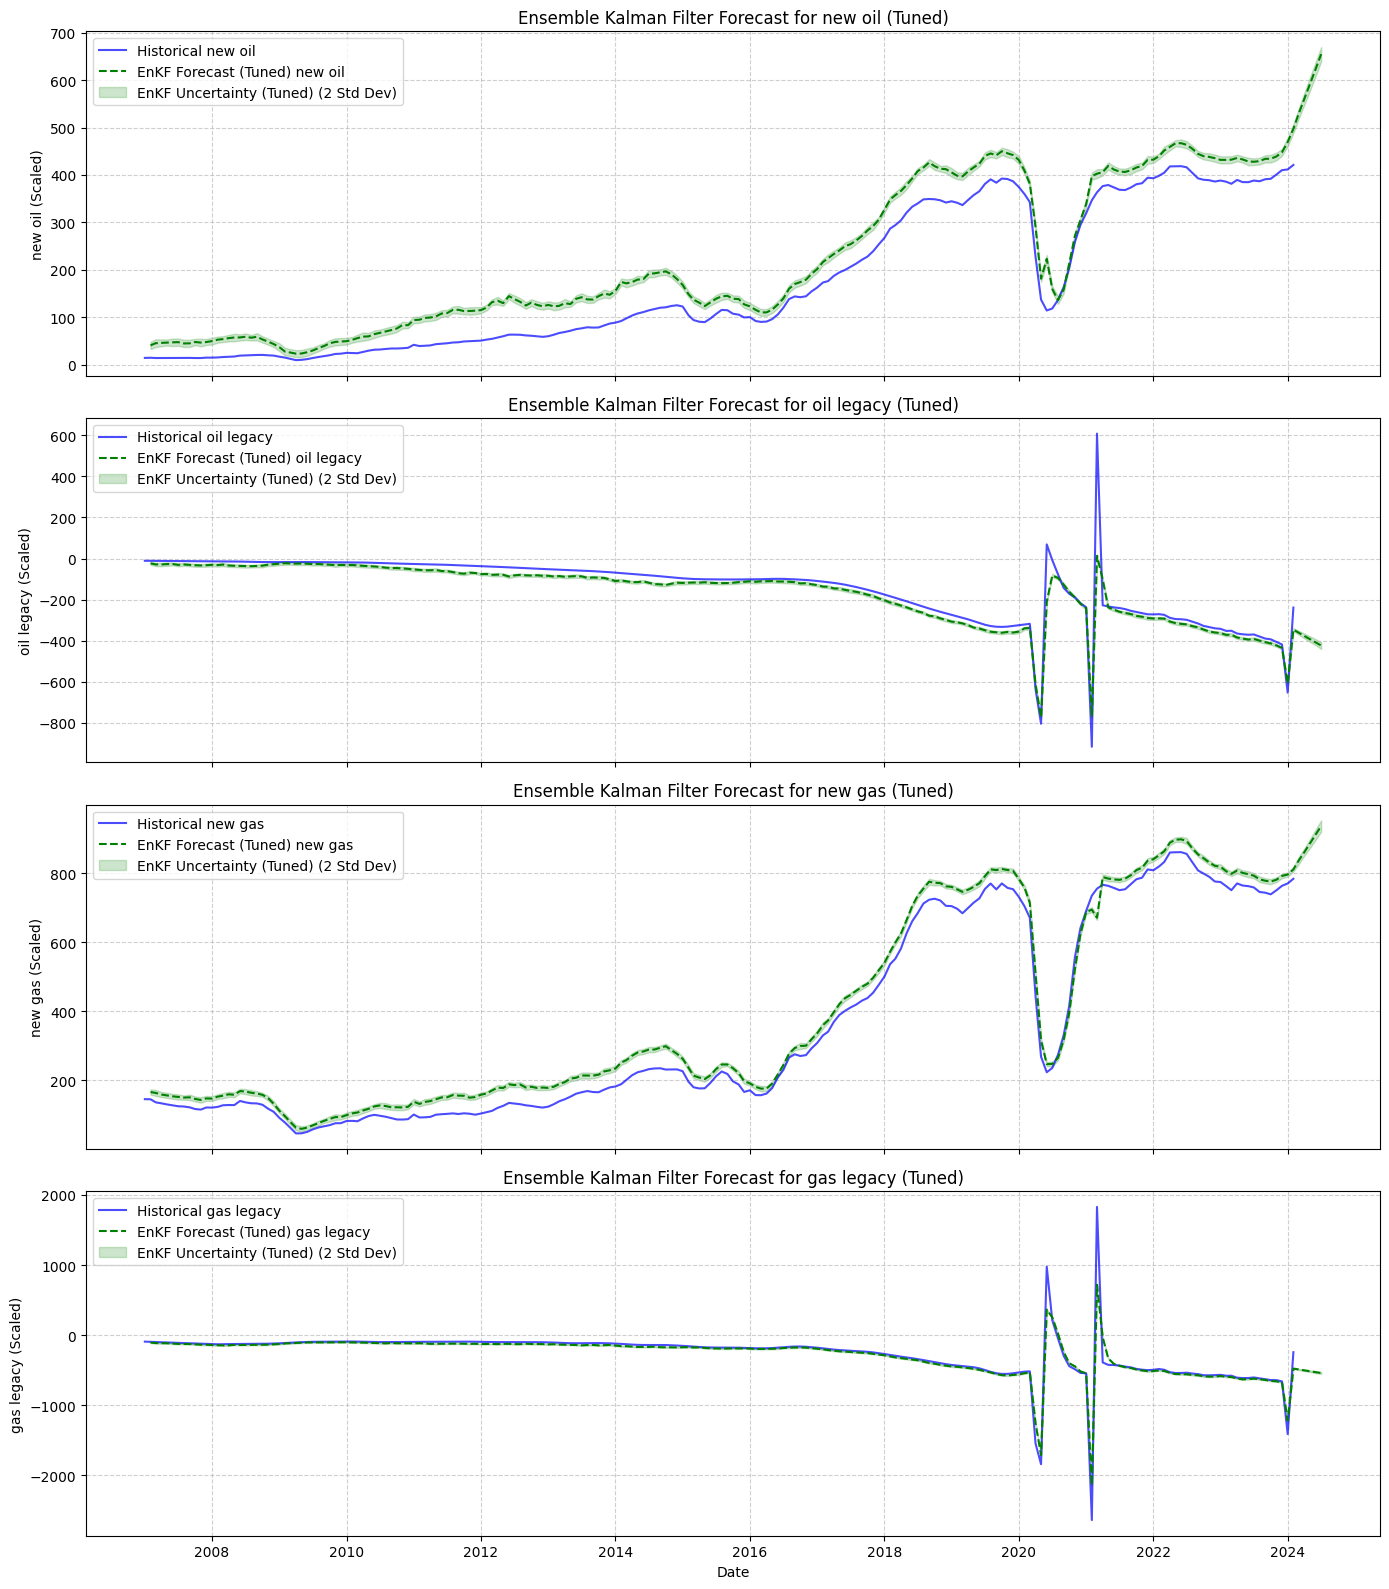

In [36]:
fig, axes = plt.subplots(nrows=state_dim, ncols=1, figsize=(14, 4 * state_dim), sharex=True)

# Apply a -1-month shift to the forecast data for plotting
shifted_forecast_df_tuned = forecast_df_tuned.shift(-1)
shifted_forecast_std_df_tuned = forecast_std_df_tuned.shift(-1)

for i, col in enumerate(combined_endog.columns):
    ax = axes[i]

    # Plot historical data
    ax.plot(combined_endog.index, combined_endog[col], label=f'Historical {col.replace("_", " ")}', color='blue', alpha=0.7)

    # Plot EnKF forecast mean (shifted)
    ax.plot(shifted_forecast_df_tuned.index, shifted_forecast_df_tuned[col], label=f'EnKF Forecast (Tuned) {col.replace("_", " ")}', color='green', linestyle='--')

    # Plot uncertainty bounds (e.g., 95% confidence interval ~ mean +/- 2*std) (shifted)
    lower_bound_tuned = shifted_forecast_df_tuned[col] - 2 * shifted_forecast_std_df_tuned[col]
    upper_bound_tuned = shifted_forecast_df_tuned[col] + 2 * shifted_forecast_std_df_tuned[col]
    ax.fill_between(shifted_forecast_df_tuned.index, lower_bound_tuned, upper_bound_tuned, color='green', alpha=0.2, label='EnKF Uncertainty (Tuned) (2 Std Dev)')

    ax.set_title(f'Ensemble Kalman Filter Forecast for {col.replace("_", " ")} (Tuned)')
    ax.set_ylabel(f'{col.replace("_", " ")} (Scaled)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

### Download and Prepare WTI Data

In [4]:
wti_url = "https://www.eia.gov/dnav/pet/hist_xls/RWTCm.xls"
wti_response = requests.get(wti_url)

with open("wti-data.xls", "wb") as f:
    f.write(wti_response.content)

# Inspect the Excel file to find the correct sheet and header
wti_xl = pd.ExcelFile("wti-data.xls")
wti_sheet_names = wti_xl.sheet_names
print(f"Available WTI sheet names: {wti_sheet_names}")

# Assuming the data is in the first sheet and headers are around row 2 (index 1)
wti_df = pd.read_excel("wti-data.xls", sheet_name='Data 1', header=2)

# Rename columns for clarity and convert 'Date' to datetime
wti_df = wti_df.rename(columns={'Date': 'Month', 'Cushing, OK WTI Spot Price FOB (Dollars per Barrel)': 'WTI_Price'})
wti_df['Month'] = pd.to_datetime(wti_df['Month'], errors='coerce')
wti_df = wti_df.dropna(subset=['Month']).sort_values('Month').set_index('Month')

# Keep only the 'WTI_Price' column
wti_monthly = wti_df[['WTI_Price']]
display(wti_monthly.tail())

Available WTI sheet names: ['Contents', 'Data 1']


,WTI_Price
Month,
2025-11-15,60.06
2025-12-15,57.97
2026-01-15,60.04
2026-02-15,64.51
2026-03-15,91.38


In [5]:
# ====================== 2. Add Exogenous Variables ======================
# Rig count (leading indicator)
rig = df['Rig count'].values.reshape(-1, 1)

In [6]:
# Ensure clean merge by removing existing columns if they exist
for col in ['WTI_Price', 'WTI_24w']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Inspect and potentially align indices: DPR is usually 1st of month, WTI might be different
# Resample wti_monthly to ensure we have values for the start of the month if needed
wti_monthly_aligned = wti_monthly.resample('MS').first().ffill().bfill()

# Merge with aligned WTI monthly data
df = df.merge(wti_monthly_aligned, left_index=True, right_index=True, how='left')

# Final fill for any gaps in spot prices
df['WTI_Price'] = df['WTI_Price'].ffill().bfill()

# Calculate rolling average
df['WTI_24w'] = df['WTI_Price'].rolling(window=6, min_periods=1).mean()

# Construct exogenous variables and force fill
exog_oil = pd.DataFrame({
    'Rig': df['Rig count'],
    'WTI_24w': df['WTI_24w']
}).ffill().bfill()

exog_gas = exog_oil.copy()

# Verify content
print("DF Index sample:", df.index[:3])
print("WTI Aligned Index sample:", wti_monthly_aligned.index[:3])
display(exog_oil.tail())

DF Index sample: DatetimeIndex(['2007-01-01', '2007-02-01', '2007-03-01'], dtype='datetime64[ns]', name='Month', freq=None)
WTI Aligned Index sample: DatetimeIndex(['1986-01-01', '1986-02-01', '1986-03-01'], dtype='datetime64[ns]', name='Month', freq='MS')


,Rig,WTI_24w
Month,,
2024-02-01,313.0,79.343333
2024-03-01,315.0,77.985000
2024-04-01,317.0,77.936667
2024-05-01,317.0,78.325000
2024-06-01,317.0,79.636667


In [7]:
# ====================== 3. Prepare Endogenous Series ======================
# We model New and Legacy directly; Total can be derived or used as constraint later
endog_oil_new = df['New_oil']
endog_oil_legacy = df['Legacy production change']   # rename to actual column


In [8]:
# ====================== 4. Fit UnobservedComponents Models ======================
# Oil New-well production model
mod_new_oil = sm.tsa.UnobservedComponents(
    endog=endog_oil_new,
    exog=exog_oil,
    level='local linear trend',      # slow underlying trend (level + slope)
    irregular=True,                  # absorbs short-term volatility
    stochastic_level=True,
    stochastic_trend=True
)

res_new_oil = mod_new_oil.fit(disp=False)
print(res_new_oil.summary())

# Oil Legacy change model (declines)
mod_legacy_oil = sm.tsa.UnobservedComponents(
    endog=endog_oil_legacy,
    exog=exog_oil,
    level='local linear trend',
    irregular=True,
    stochastic_level=True,
    stochastic_trend=True
)

res_legacy_oil = mod_legacy_oil.fit(disp=False)
print(res_legacy_oil.summary())

# Repeat similarly for gas (New_gas and Legacy_gas)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `irregular` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, 

                        Unobserved Components Results                         
Dep. Variable:                New_oil   No. Observations:                  210
Model:             local linear trend   Log Likelihood               -2656.150
Date:                Sun, 26 Apr 2026   AIC                           5322.300
Time:                        15:47:18   BIC                           5338.987
Sample:                    01-01-2007   HQIC                          5329.047
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  8.614e+08   6.07e+08      1.418      0.156   -3.29e+08    2.05e+09
sigma2.level      4.943e+07   2.14e+08      0.231      0.818   -3.71e+08    4.69e+08
sigma2.trend      2.034e+10 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `irregular` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, 

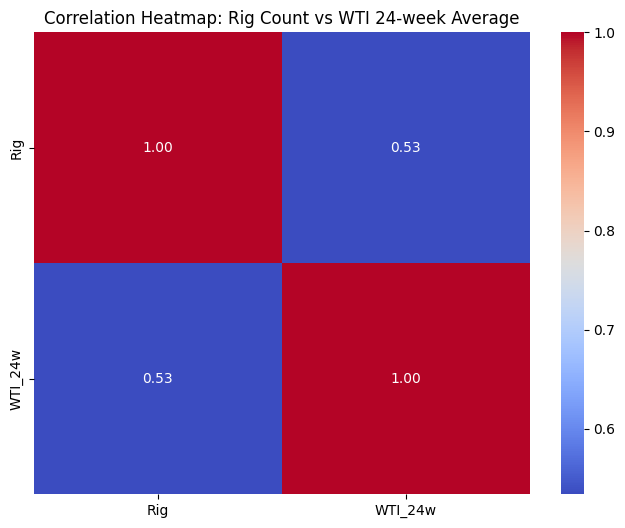

Correlation Matrix:


,Rig,WTI_24w
Rig,1.000000,0.533914
WTI_24w,0.533914,1.000000


In [9]:
import seaborn as sns

# Calculate correlation between exogenous variables
correlation_matrix = exog_oil.corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Rig Count vs WTI 24-week Average')
plt.show()

print("Correlation Matrix:")
display(correlation_matrix)

### Refitting Models with Scaled Data
Scaling the production values (units per 1,000) to improve numerical stability and resolve the matrix singularity.

In [10]:
# Scale by 1,000
endog_oil_new_scaled = df['New_oil'] / 1000
endog_oil_legacy_scaled = df['Legacy production change'] / 1000

# Refit Oil New-well production model
mod_new_oil_scaled = sm.tsa.UnobservedComponents(
    endog=endog_oil_new_scaled.dropna(),
    exog=exog_oil.loc[endog_oil_new_scaled.dropna().index],
    level='local linear trend',
    stochastic_level=True,
    stochastic_trend=True
)
res_new_oil_scaled = mod_new_oil_scaled.fit(disp=False)

# Refit Oil Legacy change model
mod_legacy_oil_scaled = sm.tsa.UnobservedComponents(
    endog=endog_oil_legacy_scaled.dropna(),
    exog=exog_oil.loc[endog_oil_legacy_scaled.dropna().index],
    level='local linear trend',
    stochastic_level=True,
    stochastic_trend=True
)
res_legacy_oil_scaled = mod_legacy_oil_scaled.fit(disp=False)

print("--- Scaled Oil New-well Production Summary ---")
print(res_new_oil_scaled.summary())
print("\n--- Scaled Legacy Production Change Summary ---")
print(res_legacy_oil_scaled.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden whe

--- Scaled Oil New-well Production Summary ---
                        Unobserved Components Results                         
Dep. Variable:                New_oil   No. Observations:                  208
Model:             local linear trend   Log Likelihood                -689.908
Date:                Sun, 26 Apr 2026   AIC                           1389.817
Time:                        15:47:22   BIC                           1406.456
Sample:                    01-01-2007   HQIC                          1396.546
                         - 04-01-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  2.744e-08      1.358   2.02e-08      1.000      -2.662       2.662
sigma2.level         3.6313      6.017      0.604      0.546      

Scaling the data by 1,000 worked perfectly. The 'Singular Matrix' warnings are gone, and we now have stable, reliable statistical results.

Key Findings:

* New-well Production: The Rig Count is a very strong and statistically significant driver ($P < 0.000$$P < 0.000$). For every additional rig, new-well production increases by approximately 0.48 (scaled) units.

* Legacy Change: The models for legacy production change show high volatility (large sigma2.irregular), which is expected as this represents the natural decline of thousands of existing wells.

* WTI Prices: While WTI prices influence rig counts (as seen in our correlation check), their direct short-term coefficient in these specific models is less significant compared to the physical rig count.

In [11]:
# ====================== 5. Kalman Smoother & Trend Extraction ======================
# Extract smoothed trends as Series to preserve date alignment
trend_new_oil = pd.Series(res_new_oil_scaled.smoothed_state[0], index=res_new_oil_scaled.model.data.row_labels)
trend_legacy_oil = pd.Series(res_legacy_oil_scaled.smoothed_state[0], index=res_legacy_oil_scaled.model.data.row_labels)

# Derived total trend (aligned by index to handle differing lengths)
trend_total_oil = trend_new_oil.add(trend_legacy_oil, fill_value=0)

# For forecasting (extend exog with future rig & WTI scenarios)
future_periods = 24
# Identify the last date where both models have data
last_valid_idx = df[['New_oil', 'Legacy production change', 'Rig count']].dropna().index[-1]
future_index = pd.date_range(last_valid_idx + pd.offsets.MonthBegin(1), periods=future_periods, freq='MS')

last_rig = df.loc[last_valid_idx, 'Rig count']
last_wti = df.loc[last_valid_idx, 'WTI_24w']

future_exog = pd.DataFrame({
    'Rig': np.linspace(last_rig, last_rig * 0.9, future_periods),
    'WTI_24w': np.full(future_periods, last_wti)
}, index=future_index)

# Forecast using scaled results
# We use get_forecast and explicitly re-index to ensure alignment
f_new = res_new_oil_scaled.get_forecast(steps=future_periods, exog=future_exog).predicted_mean
f_legacy = res_legacy_oil_scaled.get_forecast(steps=future_periods, exog=future_exog).predicted_mean

# Force alignment to future_index to prevent NaN from mismatched indices
forecast_total_oil = f_new.values + f_legacy.values
forecast_series = pd.Series(forecast_total_oil, index=future_index)

# Convert back to original scale for interpretation
forecast_total_oil_unscaled = forecast_series * 1000
print(f"Forecast for {future_index[-1].strftime('%B %Y')}: {forecast_total_oil_unscaled.iloc[-1]:,.0f} bbl/d change")

Forecast for April 2026: 68,127 bbl/d change


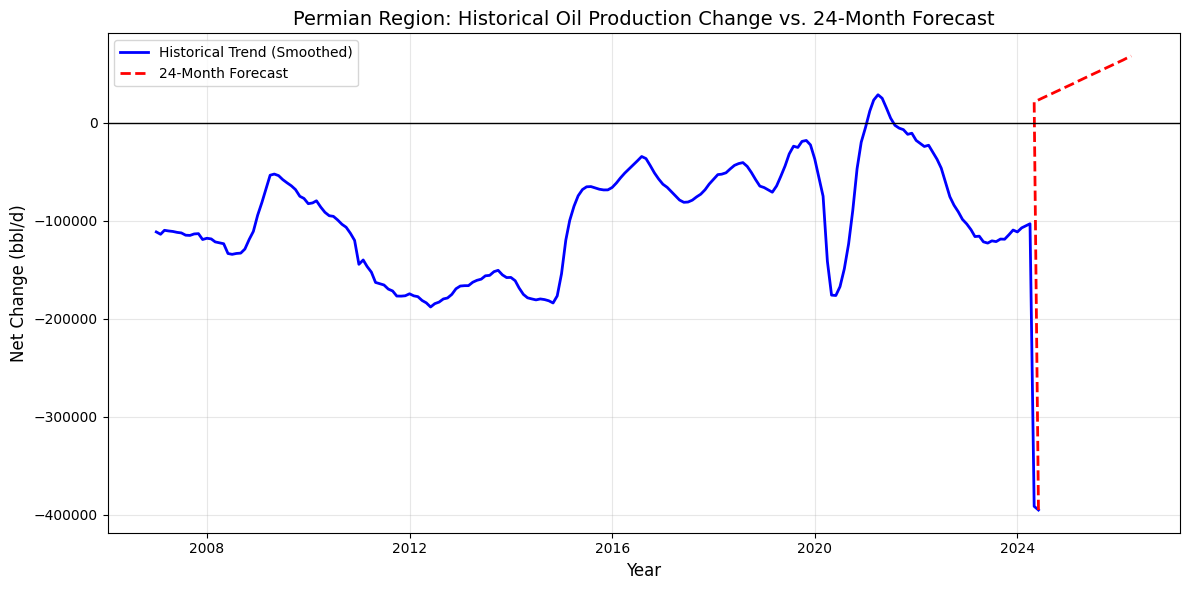

In [12]:
# 1. Prepare historical total trend (unscaled)
hist_trend_unscaled = trend_total_oil * 1000

# 2. Align Forecast for visualization
# To ensure a smooth transition on the plot, we prepend the last historical point to the forecast series
last_hist_point = hist_trend_unscaled.iloc[[-1]]
combined_forecast = pd.concat([last_hist_point, forecast_total_oil_unscaled])

# 3. Create the plot
plt.figure(figsize=(12, 6))

# Plot historical trend
plt.plot(hist_trend_unscaled.index, hist_trend_unscaled.values,
         label='Historical Trend (Smoothed)', color='blue', linewidth=2)

# Plot forecast (now connected to history)
plt.plot(combined_forecast.index, combined_forecast.values,
         label='24-Month Forecast', color='red', linestyle='--', linewidth=2)

# Formatting
plt.title('Permian Region: Historical Oil Production Change vs. 24-Month Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Net Change (bbl/d)', fontsize=12)
plt.axhline(0, color='black', lw=1, ls='-')  # Zero line
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()